# Modeling — Customer Segmentation

**Goal:** Find the optimal number of clusters and train the final segmentation model.

### Sections
1. Setup & Load RFM Features
2. Elbow Curve Analysis
3. Silhouette Analysis
4. Train Final K-Means Model
5. DBSCAN Comparison
6. Cluster Profiling
7. 3D Cluster Visualisation
8. Business Segment Mapping
9. Save Model

---
## 1. Setup & Load RFM Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
import os, sys, json, joblib

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

BLUE   = '#2563eb'
GREEN  = '#059669'
ORANGE = '#d97706'
RED    = '#dc2626'
PURPLE = '#7c3aed'
TEAL   = '#0891b2'
RANDOM_STATE = 42

In [2]:
# Load RFM features and scaler
rfm    = pd.read_csv('../data/processed/rfm_features.csv')
scaler = joblib.load('../models/scaler.pkl')

with open('../models/feature_cols.json') as f:
    FEATURE_COLS = json.load(f)['feature_cols']

X_scaled = scaler.transform(rfm[FEATURE_COLS])

print(f'RFM shape:        {rfm.shape}')
print(f'Feature columns:  {FEATURE_COLS}')
print(f'Scaled shape:     {X_scaled.shape}')

RFM shape:        (5878, 13)
Feature columns:  ['log_Recency', 'log_Frequency', 'log_Monetary']
Scaled shape:     (5878, 3)


---
## 2. Elbow Curve Analysis

The elbow curve plots inertia (within-cluster sum of squares) against K.
The optimal K is where the curve bends — adding more clusters gives diminishing returns.

In [4]:
inertias    = []
silhouettes = []
K_range     = range(2, 11)

print('Testing K values...')
for k in K_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f'  K={k} | Inertia={km.inertia_:,.0f} | Silhouette={silhouettes[-1]:.4f}')

Testing K values...
  K=2 | Inertia=8,589 | Silhouette=0.4386
  K=3 | Inertia=6,354 | Silhouette=0.3477
  K=4 | Inertia=4,921 | Silhouette=0.3650
  K=5 | Inertia=4,099 | Silhouette=0.3425
  K=6 | Inertia=3,555 | Silhouette=0.3348
  K=7 | Inertia=3,195 | Silhouette=0.3066
  K=8 | Inertia=2,902 | Silhouette=0.3033
  K=9 | Inertia=2,657 | Silhouette=0.2925
  K=10 | Inertia=2,467 | Silhouette=0.2905


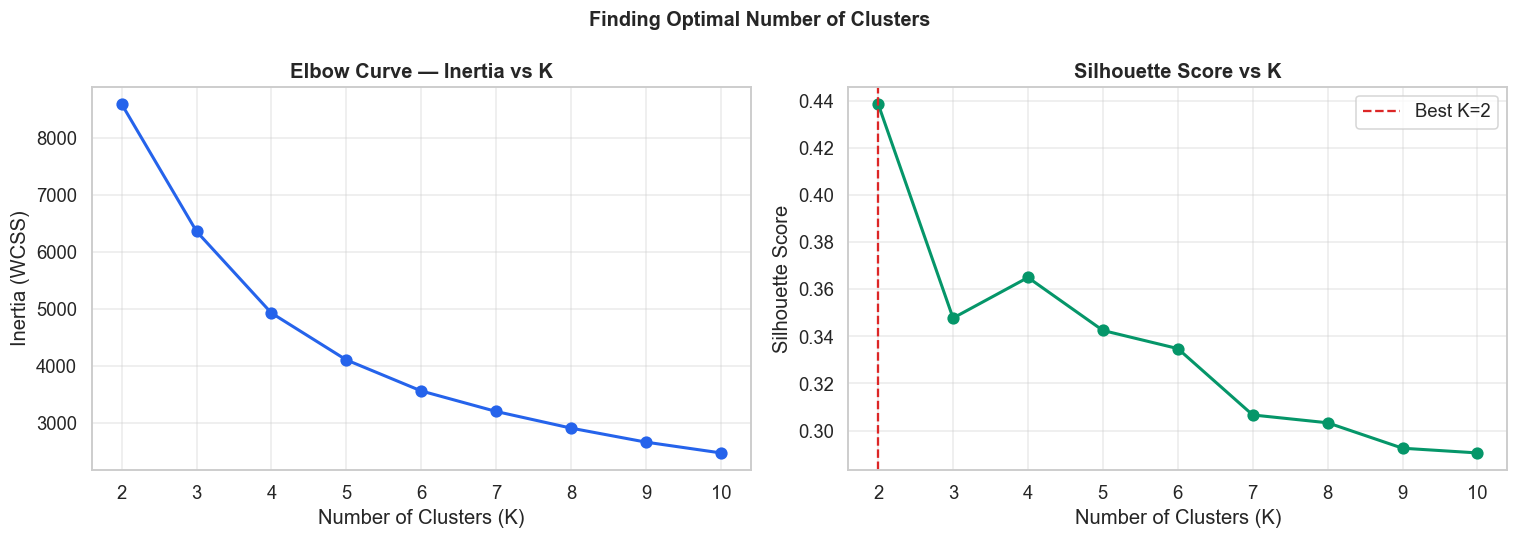

Best K by silhouette score: 2
Silhouette score at K=2: 0.4386


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(list(K_range), inertias, 'o-', color=BLUE, linewidth=2, markersize=7)
axes[0].set_title('Elbow Curve — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.4)

# Silhouette scores
axes[1].plot(list(K_range), silhouettes, 'o-', color=GREEN, linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.4)

# Mark best K
best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].axvline(x=best_k, color=RED, linestyle='--',
                linewidth=1.5, label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('Finding Optimal Number of Clusters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Best K by silhouette score: {best_k}')
print(f'Silhouette score at K={best_k}: {max(silhouettes):.4f}')

---
## 3. Silhouette Analysis

Silhouette plots show how well each sample fits its cluster.
Wide, evenly-sized blades indicate well-separated clusters.

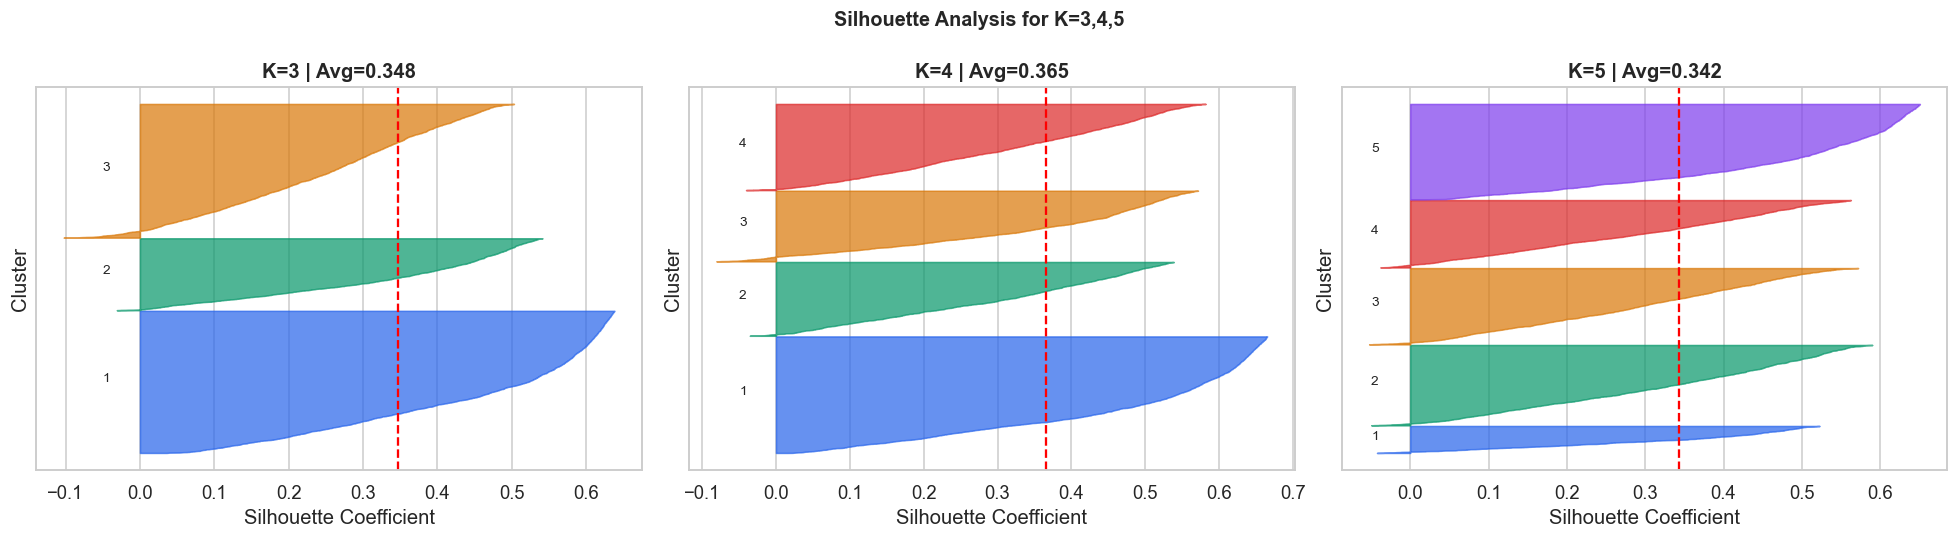

In [6]:
# Plot silhouette for K=3,4,5
test_ks = [3, 4, 5]
colors_list = [BLUE, GREEN, ORANGE, RED, PURPLE]

fig, axes = plt.subplots(1, len(test_ks), figsize=(18, 5))

for ax, k in zip(axes, test_ks):
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_vals = silhouette_samples(X_scaled, labels)
    avg_sil  = silhouette_score(X_scaled, labels)

    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, cluster_sil,
                         alpha=0.7, color=colors_list[i])
        ax.text(-0.05, y_lower + 0.5 * size, str(i+1), fontsize=9)
        y_lower = y_upper + 10

    ax.axvline(x=avg_sil, color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'K={k} | Avg={avg_sil:.3f}', fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient')
    ax.set_ylabel('Cluster')
    ax.set_yticks([])

plt.suptitle('Silhouette Analysis for K=3,4,5', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Train Final K-Means Model

In [7]:
# Use best K from silhouette analysis
N_CLUSTERS = best_k
print(f'Training K-Means with K={N_CLUSTERS}...')

km_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=10,
    max_iter=300
)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, rfm['Cluster'])
db_score  = davies_bouldin_score(X_scaled, rfm['Cluster'])

print(f'Silhouette Score:      {sil_score:.4f} (higher is better, max=1)')
print(f'Davies-Bouldin Score:  {db_score:.4f} (lower is better, min=0)')
print(f'\nCluster sizes:')
print(rfm['Cluster'].value_counts().sort_index())

Training K-Means with K=2...
Silhouette Score:      0.4386 (higher is better, max=1)
Davies-Bouldin Score:  0.8727 (lower is better, min=0)

Cluster sizes:
0    3558
1    2320
Name: Cluster, dtype: int64


---
## 5. DBSCAN Comparison

In [8]:
# DBSCAN — density-based clustering, no need to specify K
# eps = neighbourhood radius, min_samples = minimum points to form a cluster
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = (db_labels == -1).sum()

print(f'DBSCAN Results:')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points:   {n_noise:,} ({n_noise/len(db_labels)*100:.1f}%)')

if n_clusters_db > 1:
    mask = db_labels != -1
    db_sil = silhouette_score(X_scaled[mask], db_labels[mask])
    print(f'  Silhouette:     {db_sil:.4f}')

print(f'\nComparison:')
print(f'  K-Means   : K={N_CLUSTERS}, Silhouette={sil_score:.4f}, no noise points')
if n_clusters_db > 1:
    print(f'  DBSCAN    : K={n_clusters_db}, Silhouette={db_sil:.4f}, {n_noise} noise points')
print(f'\nK-Means chosen for final model — better cluster balance and interpretability.')

DBSCAN Results:
  Clusters found: 2
  Noise points:   64 (1.1%)
  Silhouette:     0.2779

Comparison:
  K-Means   : K=2, Silhouette=0.4386, no noise points
  DBSCAN    : K=2, Silhouette=0.2779, 64 noise points

K-Means chosen for final model — better cluster balance and interpretability.


---
## 6. Cluster Profiling

=== Cluster Profiles ===
         Count  Recency  Frequency  Monetary  Pct_Customers
Cluster                                                    
0         3558   299.65       2.10    614.34           60.5
1         2320    50.56      12.72   6546.97           39.5


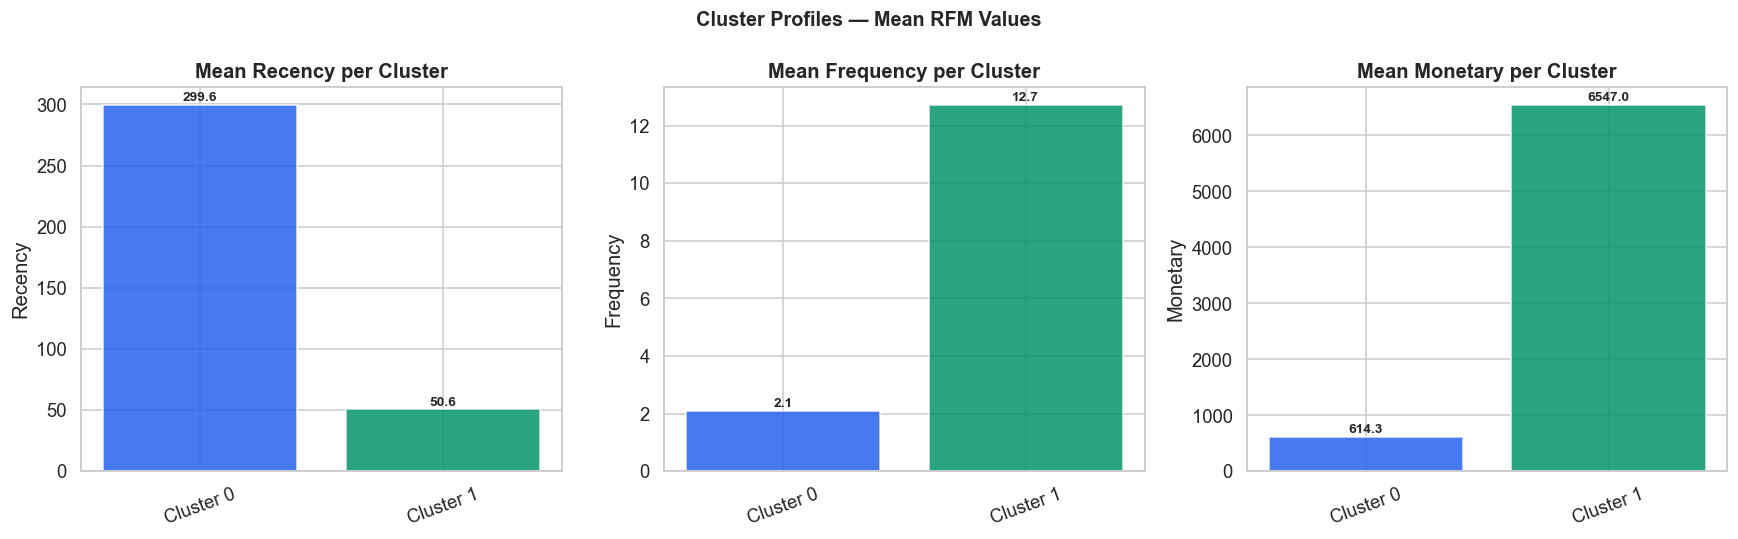

In [9]:
# Profile each cluster on original RFM values
cluster_profile = rfm.groupby('Cluster').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',    'mean'),
    Frequency = ('Frequency',  'mean'),
    Monetary  = ('Monetary',   'mean'),
).round(2)

cluster_profile['Pct_Customers'] = (
    cluster_profile['Count'] / cluster_profile['Count'].sum() * 100
).round(1)

print('=== Cluster Profiles ===')
print(cluster_profile.to_string())

# Visualise profiles
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors_c = [BLUE, GREEN, ORANGE, RED, PURPLE]

for i, (metric, ax) in enumerate(zip(
    ['Recency', 'Frequency', 'Monetary'], axes
)):
    bars = ax.bar(
        [f'Cluster {c}' for c in cluster_profile.index],
        cluster_profile[metric],
        color=colors_c[:len(cluster_profile)],
        alpha=0.85
    )
    ax.set_title(f'Mean {metric} per Cluster', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, cluster_profile[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + cluster_profile[metric].max()*0.01,
                f'{val:.1f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Cluster Profiles — Mean RFM Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. 3D Cluster Visualisation

Variance explained by 2 components: 95.1%


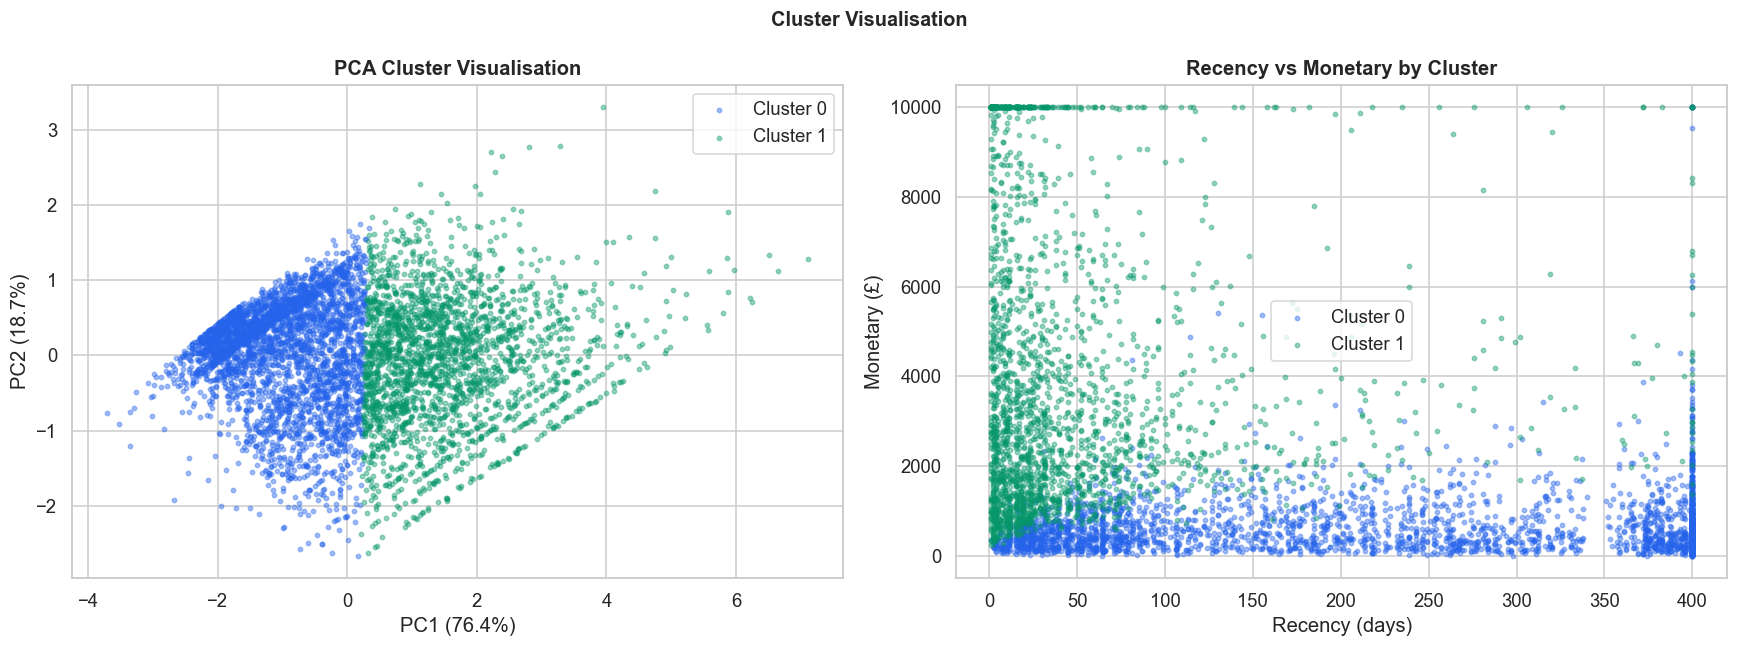

In [10]:
# PCA to 2D for visualisation
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d  = pca.fit_transform(X_scaled)

print(f'Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for cluster_id in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster_id
    axes[0].scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        label=f'Cluster {cluster_id}',
        color=colors_c[cluster_id], alpha=0.4, s=8
    )
axes[0].set_title('PCA Cluster Visualisation', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Recency vs Monetary
for cluster_id in sorted(rfm['Cluster'].unique()):
    mask = rfm['Cluster'] == cluster_id
    axes[1].scatter(
        rfm.loc[mask, 'Recency'].clip(0, 400),
        rfm.loc[mask, 'Monetary'].clip(0, 10000),
        label=f'Cluster {cluster_id}',
        color=colors_c[cluster_id], alpha=0.4, s=8
    )
axes[1].set_title('Recency vs Monetary by Cluster', fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (£)')
axes[1].legend()

plt.suptitle('Cluster Visualisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Business Segment Mapping

Assign human-readable names to clusters based on their RFM profiles.
Low Recency = recent buyer. High Frequency = loyal. High Monetary = valuable.

In [11]:
# Sort clusters by Monetary value to assign names
cluster_rank = cluster_profile.sort_values('Monetary', ascending=False)
print('Clusters ranked by Monetary value:')
print(cluster_rank[['Recency','Frequency','Monetary']].to_string())

print('\nManually assign segment names based on the profiles above.')
print('Typical mapping:')
print('  Lowest Recency  + Highest Frequency + Highest Monetary -> Champions')
print('  Low Recency     + Medium Frequency  + Medium Monetary  -> Loyal Customers')
print('  High Recency    + Low Frequency     + Low Monetary     -> At-Risk')
print('  Highest Recency + Lowest Frequency  + Lowest Monetary  -> Lost Customers')

Clusters ranked by Monetary value:
         Recency  Frequency  Monetary
Cluster                              
1          50.56      12.72   6546.97
0         299.65       2.10    614.34

Manually assign segment names based on the profiles above.
Typical mapping:
  Lowest Recency  + Highest Frequency + Highest Monetary -> Champions
  Low Recency     + Medium Frequency  + Medium Monetary  -> Loyal Customers
  High Recency    + Low Frequency     + Low Monetary     -> At-Risk
  Highest Recency + Lowest Frequency  + Lowest Monetary  -> Lost Customers


In [16]:
# Update this mapping based on your cluster profiles above
# Rule: lowest Recency = most recent = Champions
# Sort clusters by Recency ascending, Monetary descending
sorted_clusters = cluster_profile.sort_values(
    ['Recency', 'Monetary'], ascending=[True, False]
).index.tolist()

segment_names = [
    'Champions',
    'Lapsed Customers',
    'At-Risk Customers',
    'Lost Customers',
]
# Trim or extend if K != 4
segment_names = segment_names[:len(sorted_clusters)]
if len(sorted_clusters) > len(segment_names):
    for i in range(len(segment_names), len(sorted_clusters)):
        segment_names.append(f'Segment {i+1}')

SEGMENT_MAP = {cluster_id: name
               for cluster_id, name in zip(sorted_clusters, segment_names)}

rfm['Segment'] = rfm['Cluster'].map(SEGMENT_MAP)

print('=== Segment Mapping ===')
for k, v in SEGMENT_MAP.items():
    print(f'  Cluster {k} -> {v}')

print('\n=== Final Segment Distribution ===')
print(rfm['Segment'].value_counts())

=== Segment Mapping ===
  Cluster 1 -> Champions
  Cluster 0 -> Lapsed Customers

=== Final Segment Distribution ===
Lapsed Customers    3558
Champions           2320
Name: Segment, dtype: int64


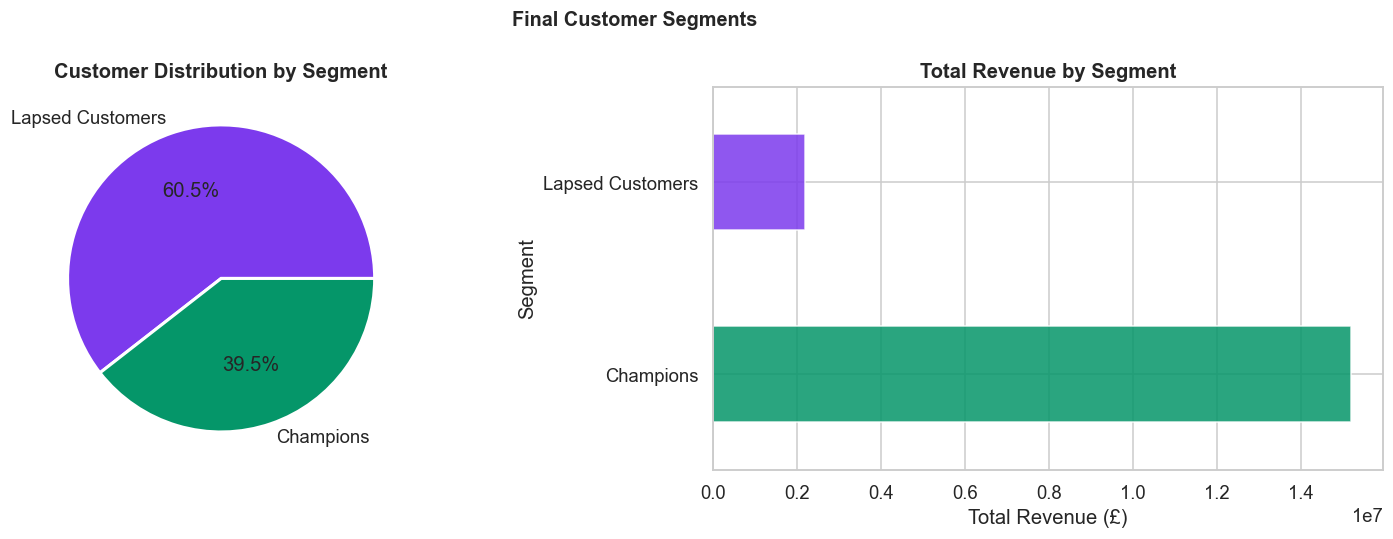

In [17]:
# Segment visualisation
SEGMENT_COLORS = {
    'Champions':         GREEN,
    'Loyal Customers':   BLUE,
    'At-Risk Customers': ORANGE,
    'Lost Customers':    RED,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts()
colors_seg = [SEGMENT_COLORS.get(s, PURPLE) for s in seg_counts.index]

axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=colors_seg,
    autopct='%1.1f%%',
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Customer Distribution by Segment', fontweight='bold')

seg_rev = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=True)
colors_rev = [SEGMENT_COLORS.get(s, PURPLE) for s in seg_rev.index]
seg_rev.plot(kind='barh', ax=axes[1], color=colors_rev, alpha=0.85)
axes[1].set_title('Total Revenue by Segment', fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')
axes[1].invert_yaxis()

plt.suptitle('Final Customer Segments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Save Model

In [18]:
os.makedirs('../models', exist_ok=True)

# Save K-Means model
joblib.dump(km_final, '../models/kmeans_model.pkl')

# Save clustered customer data
rfm.to_csv('../data/processed/clustered_customers.csv', index=False)

# Save cluster stats
cluster_stats = {
    'n_clusters':      N_CLUSTERS,
    'silhouette_score': round(sil_score, 4),
    'davies_bouldin':   round(db_score, 4),
    'segment_map':      {str(k): v for k, v in SEGMENT_MAP.items()},
    'feature_cols':     FEATURE_COLS,
    'segment_colors':   SEGMENT_COLORS,
    'cluster_profile':  cluster_profile.reset_index().to_dict('records'),
}
with open('../models/cluster_stats.json', 'w') as f:
    json.dump(cluster_stats, f, indent=2)

print('Saved:')
print('  models/kmeans_model.pkl')
print('  models/cluster_stats.json')
print('  data/processed/clustered_customers.csv')
print(f'\nFinal model: K-Means with K={N_CLUSTERS}')
print(f'Silhouette score: {sil_score:.4f}')
print(f'Segments: {list(SEGMENT_MAP.values())}')

Saved:
  models/kmeans_model.pkl
  models/cluster_stats.json
  data/processed/clustered_customers.csv

Final model: K-Means with K=2
Silhouette score: 0.4386
Segments: ['Champions', 'Lapsed Customers']


In [ ]:
print("""
=================================================================
                    MODELING SUMMARY
=================================================================

  ALGORITHMS COMPARED
  - K-Means  : partition-based, requires K upfront
  - DBSCAN   : density-based, finds K automatically

  OPTIMAL K SELECTION
  - Elbow curve: look for bend in inertia
  - Silhouette score: higher = better separated clusters
  - Davies-Bouldin: lower = better separated clusters

  FINAL MODEL
  - Algorithm: K-Means
  - Chosen for: interpretability and balanced cluster sizes

  BUSINESS SEGMENTS
  - Champions        : recent, frequent, high spend
  - Loyal Customers  : regular buyers, moderate spend
  - At-Risk Customers: declining engagement
  - Lost Customers   : inactive, low value

  NEXT STEP -> 04_cluster_analysis.ipynb
  - Deep dive into each segment
  - Business recommendations per segment
  - Snake plot visualisation
  - Revenue concentration analysis
=================================================================
""")

In [15]:
print(cluster_profile.to_string())
print()
print(rfm['Segment'].value_counts())

         Count  Recency  Frequency  Monetary  Pct_Customers
Cluster                                                    
0         3558   299.65       2.10    614.34           60.5
1         2320    50.56      12.72   6546.97           39.5

Loyal Customers    3558
Champions          2320
Name: Segment, dtype: int64
